# 2-D Finite-Element Electrostatics Solver

Jupyter notebook version of the capacitor FEM solver.  
Solves `div(ε grad V) = 0` on structured triangular meshes and computes capacitance from stored energy.

Run cells sequentially. The code is identical to the original script; only the `if __name__ == "__main__"` guard has been removed so examples can be executed cell-by-cell.

In [2]:
%matplotlib inline
"""
Two-dimensional finite-element electrostatics solver.

The current implementation status, historical changes, limitations, and future
work are documented in README.md.
"""

import os
import time
import warnings
from abc import ABC, abstractmethod
from dataclasses import dataclass
from typing import ClassVar

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.interpolate import RegularGridInterpolator
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import spsolve


# =============================================================================
# See README.md for the broader context, current status, and limitations.

# --- Execution switches (True / False) ---------------------------------------
RUN_BOUNDARY_STRESS_TEST: bool = False
"""Run the §10.4 floating-point tolerance verification on startup."""

RUN_EXACT_CHECK: bool = False
"""Run the machine-precision exact-solution validation before the examples."""

RUN_GRADED_COMPARISON: bool = True
"""For the parallel-plate example, also solve on a graded mesh and report ΔC."""

SAVE_FIGURES: bool = True
"""Write PNG files to OUTPUT_DIR."""

SHOW_PLOTS: bool = True
"""Call plt.show() after each figure (blocks until window is closed)."""

VERBOSE_CONVERGENCE_NOTES: bool = False
"""Print the long explanatory notes after convergence tables."""

PLOT_CONVERGENCE: bool = True
"""After both examples, draw a combined convergence figure (parallel-plate +
coax) with ideal/analytical references and relative error vs the reference
computed from the active parameter settings."""

# --- I/O ----------------------------------------------------------------------
OUTPUT_DIR: str = ""
"""Directory for output figures.  Empty string → current working directory."""

# --- Numerical tolerances -----------------------------------------------------
BOUNDARY_TOLERANCE_M: float = 1e-9
"""Absolute tolerance [m] for Shape.contains() boundary comparisons.
Must be >> float64 epsilon (~1e-16) and << finest mesh spacing (75 µm).
See README.md §10.4 for the full discussion."""

# --- Memory-warning heuristics ------------------------------------------------
MEMORY_ESTIMATE_COEFF_MB: float = 0.1432
"""Coefficient for the empirical peak-RSS power law: coeff * nodes**exponent."""
MEMORY_ESTIMATE_EXPONENT: float = 0.680
"""Exponent for the empirical peak-RSS power law (super-linear because of
sparse LU fill-in on a 2-D grid)."""
MEMORY_WARN_THRESHOLD_NODES: int = 1_000_000
MEMORY_CRITICAL_THRESHOLD_NODES: int = 5_000_000

# --- Graded-mesh heuristics (parallel-plate example) --------------------------


@dataclass(frozen=True)
class GradedMeshTuning:
    """Tuning knobs for the piecewise-uniform graded Cartesian mesh.
    All *spacing* fields are multipliers of the nominal grid spacing h."""
    edge_band_width_factor: float = 4.0           # width of refined zone at plate ends
    edge_band_width_min_m: float = 1.5e-3         # minimum absolute width [m]
    margin_spacing_factor: float = 2.0            # coarsen margins by this factor
    edge_spacing_factor: float = 0.5              # refine edge bands by this factor
    interior_spacing_factor: float = 1.2          # slightly coarsen plate interior
    plate_spacing_factor: float = 0.8             # spacing through conductor plates
    gap_spacing_factor: float = 0.45              # finest spacing through the gap
    min_margin_points: int = 4                    # floor on points in each margin
    min_edge_points: int = 6                      # floor on points in each edge band
    min_interior_points: int = 8                  # floor on points in plate interior
    min_plate_points: int = 4                     # floor on points through a plate
    min_gap_points: int = 10                      # floor on points through the gap
    min_fallback_interior_points: int = 4.        # floor when plate is too narrow for edge bands
    fallback_interior_spacing_factor: float = 1.0 # spacing factor used in that fallback


# Instantiate with defaults.  Replace this line to tweak globally:
GRADED_MESH_DEFAULTS: GradedMeshTuning = GradedMeshTuning()



## 1. PHYSICS CONSTANTS

In [3]:
EPS0 = 8.8541878128e-12  # vacuum permittivity [F/m]


def _validate_boundary_tolerance():
    """Guard against nonsensical boundary-tolerance values."""
    tol = BOUNDARY_TOLERANCE_M
    if not np.isfinite(tol) or tol <= 0.0:
        raise ValueError(
            "BOUNDARY_TOLERANCE_M must be a positive finite number")
    if tol <= 10 * np.finfo(float).eps:
        warnings.warn(
            "BOUNDARY_TOLERANCE_M is extremely small; geometry classification may be brittle.")


_validate_boundary_tolerance()



## 2. CONFIGURATION

In [4]:
# Geometry, material, and solver settings live in frozen dataclasses.

@dataclass(frozen=True)
class _AutoSpacingConfig:
    """Base mixin that auto-derives convergence_spacings from mesh_spacing
    when the default tuple is left untouched.

    Subclasses must set _CONVERGENCE_RATIOS and _DEFAULT_CONVERGENCE_SPACINGS
    as ClassVars.
    """
    mesh_spacing: float
    convergence_spacings: tuple

    _CONVERGENCE_RATIOS: ClassVar[tuple] = ()
    _DEFAULT_CONVERGENCE_SPACINGS: ClassVar[tuple] = ()

    def __post_init__(self):
        if not self._CONVERGENCE_RATIOS or not self._DEFAULT_CONVERGENCE_SPACINGS:
            raise NotImplementedError(
                "Subclass must set _CONVERGENCE_RATIOS and _DEFAULT_CONVERGENCE_SPACINGS")
        if self.convergence_spacings[-1] != self.mesh_spacing:
            if self.convergence_spacings == self._DEFAULT_CONVERGENCE_SPACINGS:
                object.__setattr__(
                    self, "convergence_spacings",
                    tuple(r * self.mesh_spacing for r in self._CONVERGENCE_RATIOS))
            else:
                raise ValueError(
                    "convergence_spacings[-1] must equal mesh_spacing: the finest "
                    "level of the convergence sweep is reused as the production "
                    "resolution for the detailed report and plot. Leave "
                    "convergence_spacings at its default (untouched) to have it "
                    "follow mesh_spacing automatically, or supply a full "
                    "replacement tuple ending in the new mesh_spacing.")


@dataclass(frozen=True)
class ParallelPlateConfig(_AutoSpacingConfig):
    """Parameters for the parallel-plate capacitor example.

    bottom_plate_width / top_plate_width may differ (plates are centered in
    the domain).  Defaults keep both equal (classical symmetric capacitor);
    set top_plate_width smaller to study overhang / asymmetric fringing.
    """
    plate_thickness: float = 1e-3
    gap: float = 4e-3
    dielectric_thickness: float = 2e-3
    bottom_plate_width: float = 24e-3
    top_plate_width: float = 24e-3
    domain_margin: float = 15e-3
    voltage: float = 100.0
    dielectric_eps_r: float = 4.5
    background_eps_r: float = 1.0
    mesh_spacing: float = 0.1e-3
    convergence_spacings: tuple = (0.4e-3, 0.2e-3, 0.15e-3, 0.1e-3)
    plot_margin: float = 8e-3

    _CONVERGENCE_RATIOS: ClassVar[tuple] = (4.0, 2.0, 1.5, 1.0)
    _DEFAULT_CONVERGENCE_SPACINGS: ClassVar[tuple] = (
        0.4e-3, 0.2e-3, 0.15e-3, 0.1e-3)

    def __post_init__(self):
        super().__post_init__()

        # Lengths that must be genuinely positive: zero or negative collapses
        # or inverts the geometry (e.g. a zero-thickness plate can vanish
        # from the mesh; a negative gap puts the top plate below the bottom
        # one).  See README.md known limitations.
        for name in ("plate_thickness", "gap", "bottom_plate_width",
                     "top_plate_width", "domain_margin", "mesh_spacing"):
            value = getattr(self, name)
            if not np.isfinite(value) or value <= 0.0:
                raise ValueError(
                    f"ParallelPlateConfig.{name} must be a positive, finite "
                    f"length in meters, got {value!r}.")

        # dielectric_thickness may legitimately be zero (no slab, pure air
        # gap), but not negative.
        if not np.isfinite(self.dielectric_thickness) or self.dielectric_thickness < 0.0:
            raise ValueError(
                "ParallelPlateConfig.dielectric_thickness must be a finite, "
                "non-negative length in meters (0 means no dielectric slab), "
                f"got {self.dielectric_thickness!r}.")

        # The slab is built starting at the bottom plate's surface and
        # extending upward by dielectric_thickness (_build_parallel_plate_
        # geometry), so a slab thicker than the gap itself would overlap the
        # top plate.  Equality (slab fills the whole gap) is fine.
        if self.dielectric_thickness > self.gap:
            raise ValueError(
                f"ParallelPlateConfig.dielectric_thickness "
                f"({self.dielectric_thickness * 1e3:.4g} mm) cannot exceed "
                f"gap ({self.gap * 1e3:.4g} mm): the dielectric slab sits "
                f"inside the gap, so a thicker slab would overlap the top "
                f"plate. Reduce dielectric_thickness or increase gap.")

        # Relative permittivities must stay strictly positive for the
        # stiffness matrix to remain positive definite; eps_r <= 0 solves
        # "successfully" but produces physically meaningless output (no
        # error, no warning -- verified empirically, not just in theory).
        for name in ("dielectric_eps_r", "background_eps_r"):
            value = getattr(self, name)
            if not np.isfinite(value) or value <= 0.0:
                raise ValueError(
                    f"ParallelPlateConfig.{name} must be a positive, finite "
                    f"relative permittivity, got {value!r}.")

        # capacitance_from_energy divides by (V_hi - V_lo)**2; voltage=0
        # silently returns NaN rather than raising.
        if not np.isfinite(self.voltage) or self.voltage == 0.0:
            raise ValueError(
                "ParallelPlateConfig.voltage must be finite and nonzero: "
                "capacitance_from_energy divides by (V_hi - V_lo)**2, so a "
                "zero-voltage solve carries no information about C (it "
                "silently returns NaN instead of raising).")


@dataclass(frozen=True)
class CoaxConfig(_AutoSpacingConfig):
    """Parameters for the coaxial-cable example."""
    inner_radius: float = 3e-3
    outer_radius: float = 15e-3
    domain_half_width: float = 17e-3
    voltage: float = 100.0
    dielectric_eps_r: float = 2.3
    background_eps_r: float = 1.0
    mesh_spacing: float = 0.075e-3
    convergence_spacings: tuple = (0.3e-3, 0.2e-3, 0.15e-3, 0.1e-3, 0.075e-3)

    # Exact fractions (8/3, 4/3) so derived values are as clean as possible.
    _CONVERGENCE_RATIOS: ClassVar[tuple] = (4.0, 8 / 3, 2.0, 4 / 3, 1.0)
    _DEFAULT_CONVERGENCE_SPACINGS: ClassVar[tuple] = (
        0.3e-3, 0.2e-3, 0.15e-3, 0.1e-3, 0.075e-3)

    def __post_init__(self):
        super().__post_init__()

        for name in ("inner_radius", "outer_radius", "domain_half_width",
                     "mesh_spacing"):
            value = getattr(self, name)
            if not np.isfinite(value) or value <= 0.0:
                raise ValueError(
                    f"CoaxConfig.{name} must be a positive, finite length "
                    f"in meters, got {value!r}.")

        # inner >= outer inverts the annulus; equality makes ln(outer/inner)
        # zero, dividing by zero in the analytical reference formula.
        if self.outer_radius <= self.inner_radius:
            raise ValueError(
                f"CoaxConfig.outer_radius ({self.outer_radius * 1e3:.4g} mm)"
                f" must be strictly greater than inner_radius "
                f"({self.inner_radius * 1e3:.4g} mm); both the dielectric "
                f"fill and the analytical reference "
                f"2*pi*eps/ln(outer/inner) need a genuine annular gap.")

        # The outer conductor's V=0 boundary condition is the set of nodes
        # with x^2+y^2 >= outer_radius^2 (OutsideCircle); if the meshed
        # domain doesn't reach past outer_radius, few or no nodes get that
        # condition and it silently drops out of the solve.
        if self.domain_half_width <= self.outer_radius:
            raise ValueError(
                f"CoaxConfig.domain_half_width "
                f"({self.domain_half_width * 1e3:.4g} mm) must exceed "
                f"outer_radius ({self.outer_radius * 1e3:.4g} mm), or the "
                f"outer conductor's grounded boundary has nowhere to sit "
                f"inside the meshed domain.")

        for name in ("dielectric_eps_r", "background_eps_r"):
            value = getattr(self, name)
            if not np.isfinite(value) or value <= 0.0:
                raise ValueError(
                    f"CoaxConfig.{name} must be a positive, finite relative "
                    f"permittivity, got {value!r}.")

        if not np.isfinite(self.voltage) or self.voltage == 0.0:
            raise ValueError(
                "CoaxConfig.voltage must be finite and nonzero: "
                "capacitance_from_energy divides by (V_hi - V_lo)**2, so a "
                "zero-voltage solve silently returns NaN instead of "
                "raising.")


@dataclass(frozen=True)
class PlotConfig:
    """Shared visualization tuning parameters for plot_solution()."""
    figsize: tuple = (13, 11)
    dpi: int = 140
    potential_fill_levels: int = 25
    potential_line_levels: int = 15
    streamline_density: float = 1.9
    energy_density_floor: float = 1e-4
    conductor_fill_color: str = "dimgray"
    conductor_outline_color: str = "black"
    conductor_outline_width: float = 1.3



## 3. GEOMETRY

In [5]:

class Shape(ABC):
    """Common interface for conductor and dielectric-region shapes.

    Set `voltage` to use a shape as a conductor, or `eps_r` to use it as a
    dielectric region.  Shapes compose with `|`, `&`, `-` (union, intersection,
    difference) returning new Shape instances whose contains() delegates to
    the operands.  See README.md §5.3.
    """
    voltage = None
    eps_r = None
    name = "shape"

    @abstractmethod
    def contains(self, x, y):
        """Return True where (x, y) lies inside the shape.
        x, y may be scalars or arrays; the returned mask matches their shape.
        """

    def __or__(self, other):
        return Union(self, other)

    def __and__(self, other):
        return Intersection(self, other)

    def __sub__(self, other):
        return Difference(self, other)


class Rectangle(Shape):
    """Axis-aligned rectangle [x0, x0+width] × [y0, y0+height].
    Boundary comparisons use BOUNDARY_TOLERANCE_M (see §10.4)."""

    def __init__(self, x0, y0, width, height, voltage=None, eps_r=None, name="rectangle"):
        if not np.isfinite(width) or width <= 0.0:
            raise ValueError(
                f"Rectangle '{name}': width must be positive and finite, got {width!r}")
        if not np.isfinite(height) or height <= 0.0:
            raise ValueError(
                f"Rectangle '{name}': height must be positive and finite, got {height!r}")
        self.x0, self.y0 = x0, y0
        self.width, self.height = width, height
        self.voltage = voltage
        self.eps_r = eps_r
        self.name = name

    def contains(self, x, y):
        tol = BOUNDARY_TOLERANCE_M
        return ((x >= self.x0 - tol) & (x <= self.x0 + self.width + tol) &
                (y >= self.y0 - tol) & (y <= self.y0 + self.height + tol))


class Circle(Shape):
    """Filled disk.  Boundary tolerance applied outward."""

    def __init__(self, center, radius, voltage=None, eps_r=None, name="circle"):
        if not np.isfinite(radius) or radius <= 0.0:
            raise ValueError(
                f"Circle '{name}': radius must be positive and finite, got {radius!r}")
        self.cx, self.cy = center
        self.radius = radius
        self.voltage = voltage
        self.eps_r = eps_r
        self.name = name

    def contains(self, x, y):
        tol = BOUNDARY_TOLERANCE_M
        return (x - self.cx) ** 2 + (y - self.cy) ** 2 <= (self.radius + tol) ** 2


class OutsideCircle(Shape):
    """Complement of a disk.  Boundary tolerance applied inward so that
    Circle and OutsideCircle are exact complements at the shared boundary."""

    def __init__(self, center, radius, voltage=None, eps_r=None, name="outside_circle"):
        if not np.isfinite(radius) or radius <= 0.0:
            raise ValueError(
                f"OutsideCircle '{name}': radius must be positive and finite, got {radius!r}")
        self.cx, self.cy = center
        self.radius = radius
        self.voltage = voltage
        self.eps_r = eps_r
        self.name = name

    def contains(self, x, y):
        tol = BOUNDARY_TOLERANCE_M
        return (x - self.cx) ** 2 + (y - self.cy) ** 2 >= (self.radius - tol) ** 2


class _CombinedShape(Shape):
    op_symbol = "?"

    def __init__(self, a, b, voltage=None, eps_r=None, name=None):
        self.a, self.b = a, b
        self.voltage = voltage
        self.eps_r = eps_r
        self.name = name or f"({a.name} {self.op_symbol} {b.name})"


class Union(_CombinedShape):
    op_symbol = "|"

    def contains(self, x, y):
        return self.a.contains(x, y) | self.b.contains(x, y)


class Intersection(_CombinedShape):
    op_symbol = "&"

    def contains(self, x, y):
        return self.a.contains(x, y) & self.b.contains(x, y)


class Difference(_CombinedShape):
    op_symbol = "-"

    def contains(self, x, y):
        return self.a.contains(x, y) & ~self.b.contains(x, y)



## 4. MATERIALS

In [6]:

class Material:
    """Descriptive label for a relative permittivity."""

    def __init__(self, name, eps_r):
        self.name = name
        self.eps_r = eps_r


def make_eps_r_function(regions, background_eps_r=1.0):
    """Combine dielectric-region shapes into a single ε_r(x,y) callable.
    Later entries paint over earlier ones where they overlap."""
    def eps_r_of_xy(x, y):
        x = np.asarray(x, dtype=float)
        y = np.asarray(y, dtype=float)
        eps_r = np.full(x.shape, float(background_eps_r))
        for region in regions:
            if region.eps_r is not None:
                eps_r = np.where(region.contains(x, y), region.eps_r, eps_r)
        return eps_r
    return eps_r_of_xy



## 5. MESH

In [7]:

def snap_to_grid(target, h):
    """Round a physical dimension to the nearest exact multiple of h.
    See README.md §4.3 for why this matters."""
    return round(target / h) * h


def build_graded_coords(segments):
    """Build a monotonically increasing 1-D coordinate array from
    contiguous (start, end, n_points) segments.  See README.md §11."""
    if not segments:
        raise ValueError("build_graded_coords: at least one segment required")
    parts = []
    prev_end = None
    for i, (a, b, n) in enumerate(segments):
        a, b = float(a), float(b)
        n = int(n)
        if n < 2:
            raise ValueError(
                f"build_graded_coords: segment {i} needs n >= 2, got {n}")
        if prev_end is not None and abs(a - prev_end) > 1e-12 * max(1.0, abs(a)):
            raise ValueError(
                f"build_graded_coords: segment {i} starts at {a}, but previous "
                f"ended at {prev_end} (gaps or overlaps not allowed)")
        part = np.linspace(a, b, n)
        if i > 0:
            part = part[1:]
        parts.append(part)
        prev_end = b
    return np.concatenate(parts)


def _estimate_peak_memory_gb(n_nodes):
    """Rough ballpark of peak memory [GB] for a direct sparse solve."""
    return (MEMORY_ESTIMATE_COEFF_MB * n_nodes ** MEMORY_ESTIMATE_EXPONENT) / 1024


def _warn_if_large_mesh(n_nodes, n_tris):
    """Non-blocking heads-up before a large solve."""
    est_gb = _estimate_peak_memory_gb(n_nodes)
    if n_nodes >= MEMORY_CRITICAL_THRESHOLD_NODES:
        print(f"WARNING: this mesh has {n_nodes:,} nodes ({n_tris:,} triangles). "
              f"Estimated peak memory during assembly/solve: roughly {est_gb:.1f} GB "
              f"(ballpark).  Consider a coarser mesh_spacing or the graded-Cartesian "
              f"option (build_graded_coords + Mesh(xs=..., ys=...)).")
    elif n_nodes >= MEMORY_WARN_THRESHOLD_NODES:
        print(f"Note: this mesh has {n_nodes:,} nodes ({n_tris:,} triangles), "
              f"estimated peak memory roughly {est_gb:.1f} GB (ballpark).")


class Mesh:
    """Structured triangular mesh over a rectangular domain.

    Uniform:   Mesh(x0, y0, Lx, Ly, nx=nx, ny=ny)
    Graded:    Mesh(xs=xs, ys=ys)

    Each cell is split into two triangles with a checkerboard diagonal
    pattern to avoid directional bias.
    """

    def __init__(self, x0=0.0, y0=0.0, Lx=1.0, Ly=1.0, nx=None, ny=None,
                 xs=None, ys=None):
        if xs is not None:
            self.xs = np.asarray(xs, dtype=float)
            if self.xs.ndim != 1 or self.xs.size < 2:
                raise ValueError("xs must be a 1-D array of length >= 2")
            if np.any(np.diff(self.xs) <= 0):
                raise ValueError("xs must be strictly increasing")
            nx = len(self.xs)
        else:
            if nx is None:
                raise ValueError("Mesh: either nx or xs must be supplied")
            self.xs = np.linspace(x0, x0 + Lx, int(nx))

        if ys is not None:
            self.ys = np.asarray(ys, dtype=float)
            if self.ys.ndim != 1 or self.ys.size < 2:
                raise ValueError("ys must be a 1-D array of length >= 2")
            if np.any(np.diff(self.ys) <= 0):
                raise ValueError("ys must be strictly increasing")
            ny = len(self.ys)
        else:
            if ny is None:
                raise ValueError("Mesh: either ny or ys must be supplied")
            self.ys = np.linspace(y0, y0 + Ly, int(ny))

        X, Y = np.meshgrid(self.xs, self.ys)
        self.points = np.column_stack([X.ravel(), Y.ravel()])
        self.nx, self.ny = nx, ny
        self.n_nodes = self.points.shape[0]

        _warn_if_large_mesh(self.n_nodes, 2 * (nx - 1) * (ny - 1))

        i = np.arange(nx - 1)
        j = np.arange(ny - 1)
        II, JJ = np.meshgrid(i, j)
        II = II.ravel()
        JJ = JJ.ravel()

        n00 = JJ * nx + II
        n10 = JJ * nx + (II + 1)
        n01 = (JJ + 1) * nx + II
        n11 = (JJ + 1) * nx + (II + 1)

        even = (II + JJ) % 2 == 0

        triA = np.column_stack([n00, n10, np.where(even, n11, n01)])
        triB = np.column_stack([np.where(even, n00, n10), n11, n01])

        tris = np.empty((2 * len(II), 3), dtype=int)
        tris[0::2] = triA
        tris[1::2] = triB

        self.triangles = tris
        self.n_tris = tris.shape[0]

    def centroids(self):
        pts = self.points[self.triangles]
        return pts.mean(axis=1)



## 6. SOLVER

In [8]:

def _triangle_geometry(mesh):
    """P1 shape-function gradient coefficients and triangle areas.
    Returns (b, c, area, area2) where area2 is the signed doubled area."""
    tris = mesh.triangles
    p = mesh.points
    x1, y1 = p[tris[:, 0], 0], p[tris[:, 0], 1]
    x2, y2 = p[tris[:, 1], 0], p[tris[:, 1], 1]
    x3, y3 = p[tris[:, 2], 0], p[tris[:, 2], 1]

    b1, b2, b3 = y2 - y3, y3 - y1, y1 - y2
    c1, c2, c3 = x3 - x2, x1 - x3, x2 - x1

    area2 = x1 * (y2 - y3) + x2 * (y3 - y1) + x3 * (y1 - y2)
    area = 0.5 * np.abs(area2)

    b = np.column_stack([b1, b2, b3])
    c = np.column_stack([c1, c2, c3])
    return b, c, area, area2


def evaluate_material(mesh, eps_r_of_xy):
    """Evaluate absolute permittivity (F/m) at each triangle centroid.
    Kept separate from assembly so nonlinear/iterative solves only need
    to re-call this + assemble_stiffness in a loop."""
    cxy = mesh.centroids()
    return eps_r_of_xy(cxy[:, 0], cxy[:, 1]) * EPS0


def _warn_if_degenerate_triangles(mesh, area):
    """Emit a warning if triangle areas are non-finite or suspiciously small."""
    if np.any(~np.isfinite(area)) or np.any(area <= 0.0):
        warnings.warn(
            "Encountered non-finite or non-positive triangle areas; the mesh may be degenerate.")
        return

    characteristic_area = max(1.0, np.ptp(mesh.xs) * np.ptp(mesh.ys))
    if np.min(area) < 1e-10 * characteristic_area:
        warnings.warn(
            "Some triangles are extremely small relative to the domain size; the mesh may be too fine or too distorted.")


def assemble_stiffness(mesh, eps_elem):
    """Assemble the sparse global stiffness matrix K for div(ε grad V)=0.
    Vectorised triplet assembly; duplicate (row,col) entries are summed
    by the csr_matrix constructor."""
    tris = mesh.triangles
    n = mesh.n_nodes
    b, c, area, area2 = _triangle_geometry(mesh)
    _warn_if_degenerate_triangles(mesh, area)

    Ke = b[:, :, None] * b[:, None, :] + c[:, :, None] * c[:, None, :]
    Ke = Ke * (eps_elem / (4.0 * area))[:, None, None]

    I = np.repeat(tris[:, :, None], 3, axis=2)
    J = np.repeat(tris[:, None, :], 3, axis=1)

    K = csr_matrix((Ke.ravel(), (I.ravel(), J.ravel())), shape=(n, n))
    return K, area, area2, b, c


def apply_conductors_and_solve(mesh, K, conductors):
    """Mark nodes inside conductors as Dirichlet, solve reduced system."""
    n = mesh.n_nodes
    x, y = mesh.points[:, 0], mesh.points[:, 1]

    V = np.zeros(n)
    is_fixed = np.zeros(n, dtype=bool)

    for cond in conductors:
        if cond.voltage is None:
            continue
        mask = cond.contains(x, y)
        V[mask] = cond.voltage
        is_fixed |= mask

    fixed_idx = np.flatnonzero(is_fixed)
    free_idx = np.flatnonzero(~is_fixed)

    solve_time = 0.0
    if free_idx.size == 0:
        return V, is_fixed, solve_time

    if fixed_idx.size == 0:
        warnings.warn(
            "No Dirichlet nodes were assigned; the reduced system is underdetermined. Returning the zero field.")
        return V, is_fixed, solve_time

    K_ff = K[free_idx][:, free_idx].tocsc()
    K_fd = K[free_idx][:, fixed_idx].tocsc()
    rhs = -K_fd.dot(V[fixed_idx])

    if K_ff.shape[0] == 0:
        return V, is_fixed, solve_time

    t0 = time.time()
    V[free_idx] = spsolve(K_ff, rhs)
    solve_time = time.time() - t0

    return V, is_fixed, solve_time



## 7. POST-PROCESSING

In [9]:

def compute_fields(mesh, V, eps_elem, b, c, area, area2):
    """Recover E, D, and energy density from nodal potential V.
    E and D are exactly constant per element (property of P1 elements)."""
    tris = mesh.triangles
    V1, V2, V3 = V[tris[:, 0]], V[tris[:, 1]], V[tris[:, 2]]

    dVdx = (V1 * b[:, 0] + V2 * b[:, 1] + V3 * b[:, 2]) / area2
    dVdy = (V1 * c[:, 0] + V2 * c[:, 1] + V3 * c[:, 2]) / area2

    Ex, Ey = -dVdx, -dVdy
    Emag = np.hypot(Ex, Ey)
    Dx, Dy = eps_elem * Ex, eps_elem * Ey

    energy_density = 0.5 * (Ex * Dx + Ey * Dy)
    W = np.sum(energy_density * area)

    return Ex, Ey, Emag, Dx, Dy, energy_density, W


def capacitance_from_energy(W, V_hi, V_lo):
    """Two-conductor capacitance per unit depth [F/m] from stored energy."""
    dV = V_hi - V_lo
    if dV == 0.0:
        raise ValueError(
            "capacitance_from_energy: V_hi == V_lo, so dV=0 and C = 2W/dV**2"
            " is undefined (a zero-voltage solve carries no information "
            "about C). This used to silently return NaN.")
    return 2.0 * W / dV ** 2



## 8. HIGH-LEVEL API

In [10]:

class ElectrostaticProblem:
    """Thin facade over evaluate_material → assemble_stiffness →
    apply_conductors_and_solve → compute_fields."""

    def __init__(self, mesh, background_eps_r=1.0):
        self.mesh = mesh
        self.background_eps_r = background_eps_r
        self.conductors = []
        self.dielectrics = []
        self.V = None
        self.W = None

    def add_conductor(self, shape, voltage):
        shape.voltage = voltage
        self.conductors.append(shape)
        return shape

    def add_dielectric(self, shape, eps_r=None):
        if eps_r is not None:
            shape.eps_r = eps_r
        if shape.eps_r is None:
            raise ValueError("add_dielectric: shape has no eps_r set")
        self.dielectrics.append(shape)
        return shape

    def solve(self):
        self.eps_r_of_xy = make_eps_r_function(
            self.dielectrics, self.background_eps_r)
        self.eps_elem = evaluate_material(self.mesh, self.eps_r_of_xy)
        K, area, area2, b, c = assemble_stiffness(self.mesh, self.eps_elem)
        self.V, self.is_fixed, self.solve_time = apply_conductors_and_solve(
            self.mesh, K, self.conductors)
        (self.Ex, self.Ey, self.Emag, self.Dx, self.Dy,
         self.energy_density, self.W) = compute_fields(
            self.mesh, self.V, self.eps_elem, b, c, area, area2)
        return self

    def capacitance(self, v_hi, v_lo):
        if self.W is None:
            raise RuntimeError("call .solve() before .capacitance()")
        return capacitance_from_energy(self.W, v_hi, v_lo)

    def plot(self, title, fname, xlim=None, ylim=None, style=None):
        if self.V is None:
            raise RuntimeError("call .solve() before .plot()")
        plot_solution(self.mesh, self.V, self.eps_r_of_xy, self.energy_density,
                      self.conductors, self.is_fixed, title, fname,
                      xlim=xlim, ylim=ylim, style=style,
                      Ex=getattr(self, "Ex", None), Ey=getattr(self, "Ey", None))



## 9. VISUALIZATION

In [11]:

def _project_element_field_to_nodes(mesh, values):
    """Project a per-element field to nodal values by averaging contributions."""
    nodal = np.zeros(mesh.n_nodes, dtype=float)
    counts = np.zeros(mesh.n_nodes, dtype=float)
    tris = mesh.triangles
    np.add.at(nodal, tris[:, 0], values)
    np.add.at(nodal, tris[:, 1], values)
    np.add.at(nodal, tris[:, 2], values)
    np.add.at(counts, tris[:, 0], 1.0)
    np.add.at(counts, tris[:, 1], 1.0)
    np.add.at(counts, tris[:, 2], 1.0)
    return nodal / counts


def _show_blocking_figure(fig, message=None):
    """Display a figure and wait until the user closes it.

    Uses a non-blocking show + poll loop so that the window is fully
    destroyed before the next (potentially long) computation starts.
    This avoids the macOS/TkAgg symptom where the closed window stays
    visible during the subsequent solve.
    """
    if not SHOW_PLOTS:
        plt.close(fig)
        return

    if message:
        print(message)

    fig.canvas.draw_idle()
    plt.show(block=False)          # return immediately, keep GUI alive

    # Poll until the figure is really gone; pause() processes events
    while plt.fignum_exists(fig.number):
        try:
            fig.canvas.flush_events()
        except Exception:
            pass
        plt.pause(0.05)            # ~20 Hz is plenty; keeps UI responsive

    # explicit cleanup (safe even if already closed)
    plt.close(fig)


def plot_solution(mesh, V, eps_r_of_xy, energy_density, conductors, is_fixed,
                  title, fname, xlim=None, ylim=None, style=None,
                  Ex=None, Ey=None):
    """Four-panel summary: dielectric map, equipotentials, field magnitude
    with streamlines, and energy density (log scale)."""
    style = style or PlotConfig()
    xs, ys, nx, ny = mesh.xs, mesh.ys, mesh.nx, mesh.ny
    X, Y = np.meshgrid(xs, ys)
    V_grid = V.reshape(ny, nx)
    epsr_grid = eps_r_of_xy(X, Y)

    cond_grid = np.zeros_like(X, dtype=bool)
    for cond in conductors:
        cond_grid |= cond.contains(X, Y)
    epsr_masked = np.ma.masked_where(cond_grid, epsr_grid)

    if Ex is None or Ey is None:
        dVdy_grid, dVdx_grid = np.gradient(V_grid, ys, xs)
        ExG, EyG = -dVdx_grid, -dVdy_grid
    else:
        Ex_nodes = _project_element_field_to_nodes(
            mesh, np.asarray(Ex, dtype=float))
        Ey_nodes = _project_element_field_to_nodes(
            mesh, np.asarray(Ey, dtype=float))
        ExG = Ex_nodes.reshape(ny, nx)
        EyG = Ey_nodes.reshape(ny, nx)
    EmagG = np.hypot(ExG, EyG)
    EmagG_masked = np.ma.masked_where(cond_grid, EmagG)

    tri_is_conductor = is_fixed[mesh.triangles].all(axis=1)
    energy_masked = np.ma.masked_where(tri_is_conductor, energy_density)

    cmap_blue = plt.get_cmap("Blues").copy()
    cmap_blue.set_bad(style.conductor_fill_color)
    cmap_inferno = plt.get_cmap("inferno").copy()
    cmap_inferno.set_bad(style.conductor_fill_color)
    cmap_magma = plt.get_cmap("magma").copy()
    cmap_magma.set_bad(style.conductor_fill_color)

    fig, axes = plt.subplots(2, 2, figsize=style.figsize)
    fig.suptitle(title, fontsize=14, fontweight="bold")

    def outline(ax):
        ax.contour(X, Y, cond_grid.astype(float), levels=[0.5],
                   colors=style.conductor_outline_color,
                   linewidths=style.conductor_outline_width)

    # Panel 1: dielectric map
    ax = axes[0, 0]
    pcm = ax.pcolormesh(X, Y, epsr_masked, shading="auto", cmap=cmap_blue)
    fig.colorbar(pcm, ax=ax, label=r"$\varepsilon_r$")
    outline(ax)
    ax.set_title("Dielectric map (gray = conductor)")

    # Panel 2: potential contours
    ax = axes[0, 1]
    cf = ax.contourf(
        X, Y, V_grid, levels=style.potential_fill_levels, cmap="viridis")
    ax.contour(X, Y, V_grid, levels=style.potential_line_levels,
               colors="white", linewidths=0.4, alpha=0.6)
    fig.colorbar(cf, ax=ax, label="V [Volt]")
    outline(ax)
    ax.set_title("Equipotential contours")

    # --- panel 3: field magnitude + streamlines -----------------------------
    ax = axes[1, 0]
    pcm = ax.pcolormesh(X, Y, EmagG_masked, shading="auto", cmap=cmap_inferno)
    fig.colorbar(pcm, ax=ax, label="|E| [V/m]")

    # Keep streamlines from leaking into conductor nodes.
    ExG_plot = np.where(cond_grid, 0.0, ExG)
    EyG_plot = np.where(cond_grid, 0.0, EyG)

    # Interpolate onto a uniform grid for streamplot when the mesh is graded.
    dx = np.diff(xs)
    dy = np.diff(ys)
    is_graded = (np.ptp(dx) > 1e-12 * max(1.0, np.mean(dx)) or
                 np.ptp(dy) > 1e-12 * max(1.0, np.mean(dy)))

    if is_graded:
        n_plot_x = max(nx, int(round((xs[-1] - xs[0]) / np.min(dx))) + 1)
        n_plot_y = max(ny, int(round((ys[-1] - ys[0]) / np.min(dy))) + 1)
        n_plot_x = min(n_plot_x, 400)
        n_plot_y = min(n_plot_y, 400)

        xs_u = np.linspace(xs[0], xs[-1], n_plot_x)
        ys_u = np.linspace(ys[0], ys[-1], n_plot_y)
        Xu, Yu = np.meshgrid(xs_u, ys_u)

        interp_Ex = RegularGridInterpolator(
            (ys, xs), ExG_plot, bounds_error=False, fill_value=0.0)
        interp_Ey = RegularGridInterpolator(
            (ys, xs), EyG_plot, bounds_error=False, fill_value=0.0)
        pts = np.column_stack([Yu.ravel(), Xu.ravel()])
        Ex_u = interp_Ex(pts).reshape(Yu.shape)
        Ey_u = interp_Ey(pts).reshape(Yu.shape)

        cond_u = np.zeros_like(Xu, dtype=bool)
        for cond in conductors:
            cond_u |= cond.contains(Xu, Yu)
        Ex_u = np.where(cond_u, 0.0, Ex_u)
        Ey_u = np.where(cond_u, 0.0, Ey_u)

        ax.streamplot(xs_u, ys_u, Ex_u, Ey_u,
                      color="white",
                      density=style.streamline_density,
                      linewidth=0.6, arrowsize=0.8, minlength=0.01)
    else:
        ax.streamplot(xs, ys, ExG_plot, EyG_plot,
                      color="white",
                      density=style.streamline_density,
                      linewidth=0.6, arrowsize=0.8, minlength=0.01)

    outline(ax)
    ax.set_title("Electric field + field lines")

    # Panel 4: energy density
    ax = axes[1, 1]
    vmax = energy_density.max()
    tpc = ax.tripcolor(mesh.points[:, 0], mesh.points[:, 1], mesh.triangles,
                       facecolors=energy_masked, cmap=cmap_magma,
                       norm=mcolors.LogNorm(vmin=vmax * style.energy_density_floor,
                                            vmax=vmax))
    fig.colorbar(tpc, ax=ax, label=r"energy density [J/m$^3$]")
    outline(ax)
    ax.set_title("Energy density (log scale)")

    for ax in axes.ravel():
        ax.set_xlabel("x [m]")
        ax.set_ylabel("y [m]")
        ax.set_aspect("equal")
        if xlim is not None:
            ax.set_xlim(*xlim)
        if ylim is not None:
            ax.set_ylim(*ylim)

    fig.tight_layout(rect=[0, 0, 1, 0.96])

    if SAVE_FIGURES:
        os.makedirs(os.path.dirname(fname) or ".", exist_ok=True)
        fig.savefig(fname, dpi=style.dpi)

    _show_blocking_figure(
        fig,
        "Close this plot window to continue to the next figure."
    )


def plot_convergence_study(pp_results, coax_results, graded_result=None,
                           fname=None, style=None):
    """Combined convergence figure for both worked examples.

    One figure, two panels:

    * Left  – parallel-plate: FEM C(h), ideal (fringing-free) reference
              recomputed from the snapped geometry at each h, relative
              difference vs that ideal, and optional graded-mesh marker.
    * Right – coax: FEM C(h), analytical 2πϵ/ln(b/a) reference (constant),
              and relative error (staircase / mesh discretisation error).

    All reference values are taken from the result dicts themselves, so they
    track whatever ParallelPlateConfig / CoaxConfig was used for the sweep.
    """
    style = style or PlotConfig()
    fname = fname or os.path.join(OUTPUT_DIR, "convergence_study.png")

    fig, (ax_pp, ax_cx) = plt.subplots(1, 2, figsize=(12.5, 5.2))
    fig.suptitle("Mesh convergence study", fontsize=14, fontweight="bold")

    # ----- Parallel plate ---------------------------------------------------
    h_pp = np.array([r["h"] for r in pp_results]) * 1e3          # mm
    C_pp = np.array([r["C"] for r in pp_results]) * 1e12         # pF/m
    C_id = np.array([r["C_ideal"] for r in pp_results]) * 1e12   # pF/m
    err_pp = 100.0 * (C_pp - C_id) / C_id

    color_fem = "#1f77b4"
    color_ref = "#d62728"
    color_err = "#2ca02c"
    color_grd = "#ff7f0e"

    ax_pp.plot(h_pp, C_pp, "o-", color=color_fem, lw=1.8, ms=7,
               label="FEM (uniform)")
    ax_pp.plot(h_pp, C_id, "s--", color=color_ref, lw=1.4, ms=5,
               label="Ideal (no fringing)")
    if graded_result is not None:
        ax_pp.plot(graded_result["h"] * 1e3, graded_result["C"] * 1e12,
                   "*", color=color_grd, ms=14, zorder=5,
                   label="FEM (graded)")

    ax_pp.set_xlabel("h [mm]")
    ax_pp.set_ylabel("C [pF/m]", color=color_fem)
    ax_pp.tick_params(axis="y", labelcolor=color_fem)
    ax_pp.invert_xaxis()
    ax_pp.grid(True, alpha=0.3)
    ax_pp.set_title("Parallel-plate (partial dielectric slab)")

    ax_pp2 = ax_pp.twinx()
    ax_pp2.plot(h_pp, err_pp, "^-", color=color_err, lw=1.2, ms=6, alpha=0.85,
                label="(FEM − ideal) / ideal")
    ax_pp2.set_ylabel("Relative difference [%]", color=color_err)
    ax_pp2.tick_params(axis="y", labelcolor=color_err)
    ax_pp2.axhline(0.0, color=color_err, ls=":", lw=0.8, alpha=0.5)

    lines1, labels1 = ax_pp.get_legend_handles_labels()
    lines2, labels2 = ax_pp2.get_legend_handles_labels()
    ax_pp.legend(lines1 + lines2, labels1 + labels2, loc="best", fontsize=8)

    # ----- Coax -------------------------------------------------------------
    h_cx = np.array([r["h"] for r in coax_results]) * 1e3
    C_cx = np.array([r["C"] for r in coax_results]) * 1e12
    C_an = np.array([r["C_ideal"] for r in coax_results]) * 1e12
    err_cx = 100.0 * (C_cx - C_an) / C_an

    ax_cx.plot(h_cx, C_cx, "o-", color=color_fem, lw=1.8, ms=8, label="FEM")
    ax_cx.axhline(C_an[0], color=color_ref, ls="--", lw=1.4,
                  label=r"Analytical $2\pi\varepsilon/\ln(b/a)$")

    ax_cx.set_xlabel("h [mm]")
    ax_cx.set_ylabel("C [pF/m]", color=color_fem)
    ax_cx.tick_params(axis="y", labelcolor=color_fem)
    ax_cx.invert_xaxis()
    ax_cx.grid(True, alpha=0.3)
    ax_cx.set_title("Coaxial cable (polyethylene fill)")

    ax_cx2 = ax_cx.twinx()
    ax_cx2.plot(h_cx, err_cx, "^-", color=color_err, lw=1.2, ms=4, alpha=0.85,
                label="Staircase / mesh error")
    ax_cx2.set_ylabel("Relative error [%]", color=color_err)
    ax_cx2.tick_params(axis="y", labelcolor=color_err)
    ax_cx2.axhline(0.0, color=color_err, ls=":", lw=0.8, alpha=0.5)

    lines1, labels1 = ax_cx.get_legend_handles_labels()
    lines2, labels2 = ax_cx2.get_legend_handles_labels()
    ax_cx.legend(lines1 + lines2, labels1 + labels2, loc="best", fontsize=8)

    fig.tight_layout(rect=[0, 0, 1, 0.94])

    if SAVE_FIGURES:
        os.makedirs(os.path.dirname(fname) or ".", exist_ok=True)
        fig.savefig(fname, dpi=style.dpi)
        print(f"Convergence figure saved to {fname}")

    _show_blocking_figure(
        fig,
        "Close this convergence plot window to finish."
    )



## 10. EXAMPLES & ORCHESTRATION

In [12]:

def _describe_convergence(C_values):
    """Report monotonicity of a capacitance sequence."""
    diffs = np.diff(C_values)
    if np.all(diffs > 0) or np.all(diffs < 0):
        print("The sequence above is monotonic across every tested resolution.")
    else:
        sign_changes = int(np.sum(np.diff(np.sign(diffs)) != 0))
        print(f"The sequence above is NOT monotonic (it changes direction "
              f"{sign_changes} time{'s' if sign_changes != 1 else ''} across the "
              f"tested resolutions).")


def _grid_alignment_note(config, h):
    """Check whether h divides evenly into the geometric parameters that
    directly set the capacitor's physics.  Returns 'clean' or a note."""
    checks = [("gap", config.gap),
              ("dielectric_thickness", config.dielectric_thickness),
              ("plate_thickness", config.plate_thickness),
              ("bottom_plate_width", config.bottom_plate_width),
              ("top_plate_width", config.top_plate_width)]
    notes = []
    for name, target in checks:
        ratio = target / h
        if abs(ratio - round(ratio)) > 1e-6:
            snapped = snap_to_grid(target, h)
            notes.append(f"{name} {target*1e3:.3f}->{snapped*1e3:.3f}mm")
    return "clean" if not notes else "rounded: " + ", ".join(notes)


def _snap_plate_dims(config, h):
    """Snap (plate_thickness, gap, dielectric_thickness, domain_margin) to
    grid spacing h and verify the result is still a physically valid stack.

    ParallelPlateConfig.__post_init__ already rejects an invalid combination
    at construction time, but snap_to_grid rounds each field *independently*
    to the nearest multiple of h, so a combination that was fine pre-snap can
    still be pushed over the line by rounding at a particular h (most often
    the coarsest point of a convergence sweep). Centralizing the check here
    means every solve path -- convergence sweep, production solve, graded
    mesh, and the exact-solution check -- is covered by the same guard,
    instead of each one discovering the problem on its own: previously the
    graded-mesh path failed with a generic "ys must be strictly increasing"
    and the uniform-mesh path didn't fail at all, it just silently built a
    dielectric slab that overlaps the top plate (see README.md known
    limitations). This raises a specific, actionable error instead of either.
    """
    plate_t = snap_to_grid(config.plate_thickness, h)
    gap = snap_to_grid(config.gap, h)
    dielectric_t = snap_to_grid(config.dielectric_thickness, h)
    margin = snap_to_grid(config.domain_margin, h)

    if gap <= 0.0:
        raise ValueError(
            f"At mesh spacing h={h * 1e3:.4g} mm, gap={config.gap * 1e3:.4g}"
            f" mm rounds to {gap * 1e3:.4g} mm (snap_to_grid rounds to the "
            f"nearest whole number of cells: round(gap/h) = "
            f"{round(config.gap / h)}), so the top and bottom plates would "
            f"coincide. Use a smaller mesh_spacing (aim for gap/mesh_spacing"
            f" >= ~{GRADED_MESH_DEFAULTS.min_gap_points} to keep the gap "
            f"well resolved) or a larger gap.")

    if plate_t <= 0.0:
        raise ValueError(
            f"At mesh spacing h={h * 1e3:.4g} mm, plate_thickness="
            f"{config.plate_thickness * 1e3:.4g} mm rounds to "
            f"{plate_t * 1e3:.4g} mm: the conductor plate would vanish from"
            f" the mesh interior (at best a single grid line of nodes gets "
            f"pinned, instead of a solid block). Use a smaller mesh_spacing"
            f" or a larger plate_thickness.")

    if margin <= 0.0:
        raise ValueError(
            f"At mesh spacing h={h * 1e3:.4g} mm, domain_margin="
            f"{config.domain_margin * 1e3:.4g} mm rounds to "
            f"{margin * 1e3:.4g} mm, leaving no far-field region around the"
            f" plates. Use a smaller mesh_spacing or a larger domain_margin.")

    if dielectric_t > gap:
        raise ValueError(
            f"At mesh spacing h={h * 1e3:.4g} mm, dielectric_thickness "
            f"({config.dielectric_thickness * 1e3:.4g} mm) snaps to "
            f"{dielectric_t * 1e3:.4g} mm, which exceeds the snapped gap "
            f"({gap * 1e3:.4g} mm) even though the requested values "
            f"satisfied dielectric_thickness <= gap before snapping. "
            f"Independent rounding of the two fields flipped their order at"
            f" this h. Try a different mesh_spacing, or leave more headroom"
            f" between dielectric_thickness and gap.")

    return plate_t, gap, dielectric_t, margin


def _build_parallel_plate_geometry(config, h):
    """Return (conductors, eps_r_of_xy, dims_dict) for the parallel-plate
    example at grid spacing h.  All sizes are snap_to_grid'd.

    Plates may have independent widths; they are centered in the domain
    so that overhang is symmetric.  The dielectric slab spans the wider
    plate (covers the full overlapping + overhang region).
    """
    plate_t, gap, dielectric_t, margin = _snap_plate_dims(config, h)
    bottom_w = snap_to_grid(config.bottom_plate_width, h)
    top_w = snap_to_grid(config.top_plate_width, h)

    if bottom_w <= 0.0 or top_w <= 0.0:
        raise ValueError(
            f"At mesh spacing h={h * 1e3:.4g} mm, a plate width rounds to "
            f"zero or less (bottom={bottom_w * 1e3:.4g} mm, "
            f"top={top_w * 1e3:.4g} mm): that conductor would vanish from "
            f"the mesh. Use a smaller mesh_spacing or wider plates.")

    plate_w_max = max(bottom_w, top_w)
    Lx = plate_w_max + 2 * margin
    Ly = 2 * plate_t + gap + 2 * margin

    x_bottom0 = margin + 0.5 * (plate_w_max - bottom_w)
    x_top0 = margin + 0.5 * (plate_w_max - top_w)
    y_gap_lo = margin + plate_t
    y_gap_hi = y_gap_lo + gap

    bottom_plate = Rectangle(x_bottom0, margin, bottom_w, plate_t,
                             voltage=0.0, name="bottom_plate")
    top_plate = Rectangle(x_top0, y_gap_hi, top_w, plate_t,
                          voltage=config.voltage, name="top_plate")
    conductors = [bottom_plate, top_plate]

    # dielectric_t == 0 is a valid "no slab" configuration (pure air gap);
    # skip building a zero-height Rectangle for it rather than relying on it
    # silently containing no triangle centroids (Rectangle now rejects
    # non-positive height outright -- see Shape primitives).
    dielectrics = []
    if dielectric_t > 0.0:
        slab = Rectangle(margin, y_gap_lo, plate_w_max, dielectric_t,
                         eps_r=config.dielectric_eps_r, name="dielectric_slab")
        dielectrics.append(slab)
    eps_r_of_xy = make_eps_r_function(
        dielectrics, background_eps_r=config.background_eps_r)

    dims = {
        "plate_t": plate_t, "gap": gap, "dielectric_t": dielectric_t,
        "bottom_w": bottom_w, "top_w": top_w, "plate_w_max": plate_w_max,
        "margin": margin, "Lx": Lx, "Ly": Ly,
        "x_bottom0": x_bottom0, "x_top0": x_top0,
        "y_gap_lo": y_gap_lo, "y_gap_hi": y_gap_hi,
        # keep legacy key for any leftover consumers / plot xlims
        "plate_w": plate_w_max, "x_plate0": margin,
    }
    return conductors, eps_r_of_xy, dims


def _build_graded_parallel_plate_mesh(h, dims, tune=None):
    """Construct a graded Mesh for the parallel-plate example.
    All geometry lines that were snap_to_grid'd remain exactly on mesh lines.

    x-grading is driven by the *wider* plate (outermost edges).  When the
    plates have different widths the shorter plate's edges fall inside the
    medium-resolution interior zone, which is still finer than the far-field
    margins.  This keeps the segment logic simple and identical to the
    equal-width case when bottom_w == top_w.
    """
    tune = tune or GRADED_MESH_DEFAULTS
    d = dims

    plate_w = d["plate_w_max"]
    x_plate0 = d["x_plate0"]  # == margin

    edge_band = max(tune.edge_band_width_factor *
                    h, tune.edge_band_width_min_m)
    n_margin_x = max(tune.min_margin_points,
                     round(d["margin"] / (tune.margin_spacing_factor * h)) + 1)
    n_edge = max(tune.min_edge_points,
                 round(edge_band / (tune.edge_spacing_factor * h)) + 1)
    n_interior = max(tune.min_interior_points,
                     round((plate_w - 2 * edge_band) /
                           (tune.interior_spacing_factor * h)) + 1)

    if plate_w <= 2 * edge_band:
        edge_band = 0.25 * plate_w
        n_edge = max(tune.min_edge_points,
                     round(edge_band / (tune.edge_spacing_factor * h)) + 1)
        n_interior = max(tune.min_fallback_interior_points,
                         round((plate_w - 2 * edge_band) /
                               (tune.fallback_interior_spacing_factor * h)) + 1)

    xs = build_graded_coords([
        (0.0, x_plate0, n_margin_x),
        (x_plate0, x_plate0 + edge_band, n_edge),
        (x_plate0 + edge_band, x_plate0 + plate_w - edge_band, n_interior),
        (x_plate0 + plate_w - edge_band, x_plate0 + plate_w, n_edge),
        (x_plate0 + plate_w, d["Lx"], n_margin_x),
    ])

    # Keep the dielectric interface aligned with the mesh.
    n_margin_y = max(tune.min_margin_points,
                     round(d["margin"] / (tune.margin_spacing_factor * h)) + 1)
    n_plate = max(tune.min_plate_points,
                  round(d["plate_t"] / (tune.plate_spacing_factor * h)) + 1)

    # Share the interface node so the graded split remains consistent.
    n_gap = max(tune.min_gap_points,
                round(d["gap"] / (tune.gap_spacing_factor * h)) + 1)

    # dielectric_t == 0 (no slab, pure air gap) and dielectric_t == gap
    # (slab fills the whole gap, no separate air layer) are both physically
    # valid configurations (ParallelPlateConfig allows dielectric_thickness
    # in [0, gap]).  Splitting the gap into a "glass" sub-segment and an
    # "air" sub-segment only makes sense strictly *between* those two
    # extremes -- right at either extreme, one of the two sub-segments has
    # zero length, and build_graded_coords/Mesh reject a zero-length (or
    # duplicate-point) segment as "not strictly increasing". Collapse to a
    # single full-gap segment at the extremes instead of feeding it a
    # degenerate split.
    if d["dielectric_t"] <= 0.0 or d["dielectric_t"] >= d["gap"]:
        gap_segments = [(d["y_gap_lo"], d["y_gap_hi"], n_gap)]
    else:
        y_diel = d["y_gap_lo"] + d["dielectric_t"]
        frac = d["dielectric_t"] / d["gap"]
        n_diel = max(tune.min_gap_points // 2, round(n_gap * frac))
        n_air = max(tune.min_gap_points // 2, n_gap - n_diel + 1)
        gap_segments = [
            (d["y_gap_lo"], y_diel, n_diel),  # glass
            (y_diel, d["y_gap_hi"], n_air),  # air
        ]

    ys = build_graded_coords(
        [
            (0.0, d["margin"], n_margin_y),
            (d["margin"], d["y_gap_lo"], n_plate),
            *gap_segments,
            (d["y_gap_hi"], d["y_gap_hi"] + d["plate_t"], n_plate),
            (d["y_gap_hi"] + d["plate_t"], d["Ly"], n_margin_y),
        ]
    )

    return Mesh(xs=xs, ys=ys)


def _solve_parallel_plate(config, h, use_graded=False):
    """Build and solve the parallel-plate problem at nominal spacing h."""
    conductors, eps_r_of_xy, d = _build_parallel_plate_geometry(config, h)

    if use_graded:
        mesh = _build_graded_parallel_plate_mesh(h, d)
    else:
        mesh = Mesh(0, 0, d["Lx"], d["Ly"],
                    nx=round(d["Lx"] / h) + 1, ny=round(d["Ly"] / h) + 1)

    eps_elem = evaluate_material(mesh, eps_r_of_xy)
    K, area, area2, b, c = assemble_stiffness(mesh, eps_elem)
    V, is_fixed, solve_time = apply_conductors_and_solve(mesh, K, conductors)
    Ex, Ey, Emag, Dx, Dy, energy_density, W = compute_fields(
        mesh, V, eps_elem, b, c, area, area2)
    C = capacitance_from_energy(W, config.voltage, 0.0)
    # Ideal (fringing-free) formula uses the overlapping width
    overlap_w = min(d["bottom_w"], d["top_w"])
    C_ideal = (overlap_w * EPS0 /
               (d["dielectric_t"] / config.dielectric_eps_r +
                (d["gap"] - d["dielectric_t"]) / config.background_eps_r))

    result = dict(h=h, mesh=mesh, conductors=conductors, eps_r_of_xy=eps_r_of_xy,
                  V=V, is_fixed=is_fixed, energy_density=energy_density,
                  Ex=Ex, Ey=Ey, C=C, C_ideal=C_ideal, solve_time=solve_time, graded=use_graded)
    result.update(d)
    return result


def _print_parallel_plate_convergence(results, config):
    """Pretty-print the parallel-plate convergence table."""
    print(f"{'h [mm]':>9s}{'nodes':>9s}{'solve [s]':>11s}{'C [pF/m]':>12s}{'change':>9s}  grid alignment")
    prev_C = None
    C_values = []
    for result in results:
        h = result["h"]
        C = result["C"]
        change = "" if prev_C is None else f"{100*(C-prev_C)/prev_C:+.2f}%"
        alignment = _grid_alignment_note(config, h)
        print(f"{h*1e3:9.3f}{result['mesh'].n_nodes:9d}{result['solve_time']:11.3f}"
              f"{C*1e12:12.3f}{change:>9s}  {alignment}")
        prev_C = C
        C_values.append(C)
    _describe_convergence(C_values)


def _print_parallel_plate_convergence_notes():
    print("Two distinct effects are mixed together in the table above, and the")
    print("'grid alignment' column separates them. The core assembly/solve")
    print("pipeline reproduces an exact, fringing-free analytical case to")
    print("machine precision at every resolution tested (README section 8.1) --")
    print("so genuine FEM discretization error is real but small, visible in")
    print("the 'clean' rows above. A 'rounded' row is different: snap_to_grid")
    print("(README section 4.3) has adjusted a physically meaningful dimension")
    print("(the gap or the dielectric thickness) to the nearest value that h")
    print("can represent exactly, because the target didn't divide evenly into")
    print("that h -- meaning a 'rounded' row is genuinely simulating a slightly")
    print("different capacitor, not just resolving the same one more finely.")
    print("Separately, and unrelated to grid alignment: the field concentrates")
    print("sharply at the plate's corner (a geometric singularity), and each h")
    print("above is an independent structured mesh rather than a nested")
    print("refinement of the previous one, so successive CLEAN levels are still")
    print("not guaranteed to bracket the true answer monotonically (see")
    print("LIMITATIONS AND FUTURE WORK). For a convergence study, prefer h")
    print("values that divide evenly into every geometric parameter you care")
    print("about; treat the finest clean level as accurate to roughly the")
    print("spread shown among the other clean rows.")


def example_parallel_plate(config=None):
    """Parallel-plate capacitor with partial dielectric slab."""
    config = config or ParallelPlateConfig()

    print("=" * 72)
    print("EXAMPLE 1: Parallel-plate capacitor, partially filled with a dielectric slab")
    print("=" * 72)
    print(f"  bottom plate (0 V): {config.bottom_plate_width*1e3:.1f} mm wide")
    print(f"  top plate ({config.voltage:g} V): {config.top_plate_width*1e3:.1f} mm wide"
          f"{'  (shorter → asymmetric fringing)' if config.top_plate_width != config.bottom_plate_width else ''}")
    print()

    print("Mesh convergence (physical geometry fixed, only h changes):")
    results = [_solve_parallel_plate(config, h)
               for h in config.convergence_spacings]
    _print_parallel_plate_convergence(results, config)
    if VERBOSE_CONVERGENCE_NOTES:
        _print_parallel_plate_convergence_notes()
    print()

    # Production solve: finest uniform level (last convergence entry)
    uniform = results[-1]
    C_uniform = uniform["C"]
    C_ideal = uniform["C_ideal"]
    print(f"Uniform mesh (finest clean level): {uniform['mesh'].n_nodes} nodes, "
          f"{uniform['mesh'].n_tris} triangles (h = {uniform['h']*1e3:.3f} mm)")
    print(f"FEM capacitance (uniform) : {C_uniform*1e12:9.3f} pF/m")
    print(f"Ideal, no fringing        : {C_ideal*1e12:9.3f} pF/m")
    print(f"Difference                : {100*(C_uniform-C_ideal)/C_ideal:+6.2f} %  "
          f"(FEM > ideal is expected: it also captures fringing)")
    print()

    # Optional graded comparison
    if RUN_GRADED_COMPARISON:
        print("Graded Cartesian mesh (same nominal h, refined near edges & gap):")
        graded = _solve_parallel_plate(config, uniform["h"], use_graded=True)
        C_graded = graded["C"]
        print(f"mesh: {graded['mesh'].n_nodes} nodes, {graded['mesh'].n_tris} triangles "
              f"(graded, nominal h = {graded['h']*1e3:.3f} mm)")
        print(f"FEM capacitance (graded)  : {C_graded*1e12:9.3f} pF/m")
        print(
            f"Delta vs uniform          : {100*(C_graded-C_uniform)/C_uniform:+.2f} %")
        print("Capacitance is per unit depth into the page; multiply by the actual "
              "plate depth in meters for total farads.")
        print("The graded mesh is the dependency-free intermediate step of README §11; "
              "it improves resolution of the corner singularity without adding any "
              "native dependency.")

        plot_solution(graded["mesh"], graded["V"], graded["eps_r_of_xy"],
                      graded["energy_density"], graded["conductors"], graded["is_fixed"],
                      "Parallel-plate capacitor (glass slab in an air gap) — graded mesh",
                      os.path.join(OUTPUT_DIR, "example1_parallel_plate.png"),
                      Ex=graded["Ex"], Ey=graded["Ey"],
                      xlim=(graded["x_plate0"] - config.plot_margin,
                            graded["x_plate0"] + graded["plate_w"] + config.plot_margin),
                      ylim=(graded["margin"] - config.plot_margin,
                            graded["margin"] + config.plot_margin
                            + 2 * graded["plate_t"] + graded["gap"]))
        return C_graded, C_ideal, results, graded

    # If graded comparison is disabled, plot the uniform result instead
    plot_solution(uniform["mesh"], uniform["V"], uniform["eps_r_of_xy"],
                  uniform["energy_density"], uniform["conductors"], uniform["is_fixed"],
                  "Parallel-plate capacitor (glass slab in an air gap)",
                  os.path.join(OUTPUT_DIR, "example1_parallel_plate.png"),
                  Ex=uniform["Ex"], Ey=uniform["Ey"],
                  xlim=(uniform["x_plate0"] - config.plot_margin,
                        uniform["x_plate0"] + uniform["plate_w"] + config.plot_margin),
                  ylim=(uniform["margin"] - config.plot_margin,
                        uniform["margin"] + config.plot_margin
                        + 2 * uniform["plate_t"] + uniform["gap"]))
    return C_uniform, C_ideal, results, None


def _solve_coax(config, h):
    """Build and solve the coax problem at grid spacing h."""
    nx = round(2 * config.domain_half_width / h) + 1
    ny = nx

    inner = Circle((0, 0), config.inner_radius, voltage=config.voltage,
                   name="inner_conductor")
    outer = OutsideCircle((0, 0), config.outer_radius, voltage=0.0,
                          name="outer_conductor")
    conductors = [inner, outer]

    fill = Circle((0, 0), config.outer_radius, eps_r=config.dielectric_eps_r,
                  name="dielectric_fill")
    eps_r_of_xy = make_eps_r_function(
        [fill], background_eps_r=config.background_eps_r)

    half = config.domain_half_width
    mesh = Mesh(-half, -half, 2 * half, 2 * half, nx=nx, ny=ny)
    eps_elem = evaluate_material(mesh, eps_r_of_xy)
    K, area, area2, b, c = assemble_stiffness(mesh, eps_elem)
    V, is_fixed, solve_time = apply_conductors_and_solve(mesh, K, conductors)
    Ex, Ey, Emag, Dx, Dy, energy_density, W = compute_fields(
        mesh, V, eps_elem, b, c, area, area2)
    C = capacitance_from_energy(W, config.voltage, 0.0)
    C_ideal = (2 * np.pi * EPS0 * config.dielectric_eps_r
               / np.log(config.outer_radius / config.inner_radius))

    return dict(h=h, mesh=mesh, conductors=conductors, eps_r_of_xy=eps_r_of_xy,
                V=V, is_fixed=is_fixed, energy_density=energy_density,
                Ex=Ex, Ey=Ey, C=C, C_ideal=C_ideal, solve_time=solve_time)


def example_coax(config=None):
    """Coaxial cable with polyethylene dielectric fill."""
    config = config or CoaxConfig()

    print()
    print("=" * 72)
    print("EXAMPLE 2: Coaxial capacitor (polyethylene-filled)")
    print("=" * 72)

    print("Mesh convergence (smooth circular boundary, no sharp corner):")
    print(
        f"{'h [mm]':>9s}{'nodes':>9s}{'solve [s]':>11s}{'C [pF/m]':>12s}{'error':>9s}")
    results = [_solve_coax(config, h) for h in config.convergence_spacings]
    C_values = []
    for result in results:
        h = result["h"]
        C = result["C"]
        err = 100 * (C - result["C_ideal"]) / result["C_ideal"]
        print(f"{h*1e3:9.3f}{result['mesh'].n_nodes:9d}{result['solve_time']:11.3f}"
              f"{C*1e12:12.3f}{err:+8.2f}%")
        C_values.append(C)
    _describe_convergence(C_values)
    if VERBOSE_CONVERGENCE_NOTES:
        print("Error shrinks toward 0% overall. These five points happen to be")
        print("monotonic, but that describes this specific sweep, not a general")
        print("guarantee -- finer intermediate resolutions reveal small reversals")
        print("too (same non-nested-mesh effect as example 1, far smaller in size;")
        print("see README.md section 8.2).")
    print()

    result = results[-1]
    C, C_ideal = result["C"], result["C_ideal"]
    print(f"mesh: {result['mesh'].n_nodes} nodes, {result['mesh'].n_tris} triangles "
          f"(h = {result['h']*1e3:.3f} mm)")
    print(f"FEM capacitance             : {C*1e12:9.3f} pF/m")
    print(f"Analytical 2*pi*eps/ln(b/a) : {C_ideal*1e12:9.3f} pF/m")
    print(f"Difference                  : {100*(C-C_ideal)/C_ideal:+6.2f} %  "
          f"(mesh / staircase discretization error)")

    plot_solution(result["mesh"], result["V"], result["eps_r_of_xy"],
                  result["energy_density"], result["conductors"], result["is_fixed"],
                  "Coaxial capacitor (polyethylene dielectric)",
                  os.path.join(OUTPUT_DIR, "example2_coax.png"),
                  Ex=result["Ex"], Ey=result["Ey"])
    return C, C_ideal, results


def _solve_exact_check(config, h):
    """Full-width-plate variant: fringing is geometrically impossible."""
    plate_t, gap, dielectric_t, margin = _snap_plate_dims(config, h)

    Lx = snap_to_grid(max(config.bottom_plate_width,
                      config.top_plate_width), h)
    Ly = 2 * plate_t + gap + 2 * margin
    nx = round(Lx / h) + 1
    ny = round(Ly / h) + 1

    y_gap_lo = margin + plate_t
    y_gap_hi = y_gap_lo + gap

    overhang = Lx
    bottom_plate = Rectangle(-overhang, margin, Lx + 2 * overhang, plate_t,
                             voltage=0.0, name="bottom_plate")
    top_plate = Rectangle(-overhang, y_gap_hi, Lx + 2 * overhang, plate_t,
                          voltage=config.voltage, name="top_plate")
    conductors = [bottom_plate, top_plate]

    # dielectric_t == 0 is a valid "no slab" configuration; see the matching
    # comment in _build_parallel_plate_geometry.
    dielectrics = []
    if dielectric_t > 0.0:
        slab = Rectangle(-overhang, y_gap_lo, Lx + 2 * overhang, dielectric_t,
                         eps_r=config.dielectric_eps_r, name="dielectric_slab")
        dielectrics.append(slab)
    eps_r_of_xy = make_eps_r_function(
        dielectrics, background_eps_r=config.background_eps_r)

    mesh = Mesh(0, 0, Lx, Ly, nx=nx, ny=ny)
    eps_elem = evaluate_material(mesh, eps_r_of_xy)
    K, area, area2, b, c = assemble_stiffness(mesh, eps_elem)
    V, is_fixed, solve_time = apply_conductors_and_solve(mesh, K, conductors)
    Ex, Ey, Emag, Dx, Dy, energy_density, W = compute_fields(
        mesh, V, eps_elem, b, c, area, area2)
    C = capacitance_from_energy(W, config.voltage, 0.0)
    C_exact = (Lx * EPS0 /
               (dielectric_t / config.dielectric_eps_r +
                (gap - dielectric_t) / config.background_eps_r))

    return dict(h=h, mesh=mesh, C=C, C_exact=C_exact, solve_time=solve_time)


def example_exact_check(config=None, spacings=(0.5e-3, 0.25e-3, 0.125e-3, 0.0625e-3)):
    """Exact-solution validation: full-width plates, no fringing possible."""
    config = config or ParallelPlateConfig()

    print("=" * 72)
    print("EXACT-SOLUTION CHECK: full-width plates, no fringing possible")
    print("=" * 72)
    print("Same materials, gap, and dielectric split as the parallel-plate")
    print("example above, but the plates now extend across (and past) the")
    print("whole domain, so the series-capacitor formula is exact here, not")
    print("idealized. This isolates the solver's own correctness from the")
    print("mesh's ability to represent any particular boundary shape.")
    print()

    print(f"{'h [mm]':>9s}{'nodes':>9s}{'solve [s]':>11s}{'C [pF/m]':>16s}"
          f"{'C_exact [pF/m]':>18s}{'error':>12s}{'rel. diff':>13s}")
    results = []
    for h in spacings:
        result = _solve_exact_check(config, h)
        err = 100 * (result["C"] - result["C_exact"]) / result["C_exact"]
        rel_diff = abs(result["C"] - result["C_exact"]) / result["C_exact"]
        print(f"{h*1e3:9.4f}{result['mesh'].n_nodes:9d}{result['solve_time']:11.3f}"
              f"{result['C']*1e12:16.8f}{result['C_exact']*1e12:18.8f}{err:+11.6f}%"
              f"{rel_diff:13.2e}")
        results.append(result)
    print()
    print("The 'error' column displays as 0.000000% at 6 decimal places, but")
    print("is not literally zero -- 'rel. diff' shows the true residual, a few")
    print("times float64 epsilon (2.22e-16), i.e. exact to machine precision:")
    print("ordinary floating-point roundoff from the sparse solve, the same at")
    print("every resolution, not a limitation of the method or the mesh. This")
    print("confirms the core FEM machinery -- assembly, boundary conditions,")
    print("energy integration -- has no implementation bugs at any of these")
    print("resolutions, including the two-layer dielectric handling. Any error")
    print("elsewhere in this project comes from the mesh, not the math")
    print("(README.md section 8.1).")

    return results[-1]["C"], results[-1]["C_exact"]


def verify_boundary_tolerance():
    """§10.4 stress test: perturbed boundary coordinates must still classify
    correctly thanks to BOUNDARY_TOLERANCE_M."""
    print("=" * 72)
    print("§10.4 BOUNDARY-TOLERANCE STRESS TEST")
    print("=" * 72)

    x0 = 0.015
    width = 0.024
    y0 = 0.016
    height = 0.001
    rect = Rectangle(x0, y0, width, height, voltage=0.0)
    x_edge = x0 + width

    candidates = [
        ("literal 0.039",           0.039),
        ("1.5 * 0.026",             1.5 * 0.026),
        ("39e-3",                   39e-3),
        ("float64(0.015)+0.024",    np.float64(0.015) + np.float64(0.024)),
        ("1.5 * 0.1e-3 * 260",      1.5 * 0.1e-3 * 260),
        ("nudged +5e-15",           x_edge + 5e-15),
        ("nudged -5e-15",           x_edge - 5e-15),
    ]

    points = np.array([c[1] for c in candidates])
    y = np.full_like(points, y0 + 0.5 * height)
    mask = rect.contains(points, y)

    print(f"BOUNDARY_TOLERANCE_M = {BOUNDARY_TOLERANCE_M} m")
    print(f"Exact edge x = {x_edge}")
    print()
    print(f"{'source':>22s}  {'reconstructed x':>20s}  {'delta':>12s}  inside?")
    for (name, xi), inside in zip(candidates, mask):
        delta = xi - x_edge
        print(f"{name:>22s}  {xi:20.16e}  {delta:12.2e}  {bool(inside)}")

    if not np.all(mask):
        print()
        print("FAILURE: at least one near-edge coordinate was classified outside.")
        print("The tolerance is not large enough for the observed ULP noise.")
        return False

    print()
    print("All near-edge coordinates classified as INSIDE -- tolerance is")
    print("doing its job. (A strict <= comparison would have failed for some")
    print("of the reconstructed values above.)")
    print()
    return True


def print_summary(C1, C1_ideal, C2, C2_ideal, elapsed):
    """Final summary table."""
    print()
    print("=" * 72)
    print("SUMMARY")
    print("=" * 72)
    print(f"{'Case':32s}{'FEM [pF/m]':>16s}{'Analytical [pF/m]':>20s}")
    print(f"{'Parallel plate (dielectric slab)':32s}{C1*1e12:16.3f}{C1_ideal*1e12:20.3f}")
    print(f"{'Coax (polyethylene)':32s}{C2*1e12:16.3f}{C2_ideal*1e12:20.3f}")
    print()
    print(f"total runtime: {elapsed:.2f} s")
    if SAVE_FIGURES:
        print(f"Figures written under {OUTPUT_DIR}/ "
              f"(example1_parallel_plate.png, example2_coax.png"
              f"{', convergence_study.png' if PLOT_CONVERGENCE else ''})")



## Main Execution

Run the examples and convergence study.  
The `if __name__ == "__main__":` guard has been removed so this runs directly in the notebook.

EXAMPLE 1: Parallel-plate capacitor, partially filled with a dielectric slab
  bottom plate (0 V): 24.0 mm wide
  top plate (100 V): 24.0 mm wide

Mesh convergence (physical geometry fixed, only h changes):
   h [mm]    nodes  solve [s]    C [pF/m]   change  grid alignment
    0.400    12467      0.026     101.970           rounded: plate_thickness 1.000->0.800mm
    0.200    49051      0.198     101.929   -0.04%  clean
    0.150    87362      0.497      98.815   -3.05%  rounded: gap 4.000->4.050mm, dielectric_thickness 2.000->1.950mm, plate_thickness 1.000->1.050mm
    0.100   195301      1.801     101.844   +3.06%  clean
The sequence above is NOT monotonic (it changes direction 1 time across the tested resolutions).

Uniform mesh (finest clean level): 195301 nodes, 388800 triangles (h = 0.100 mm)
FEM capacitance (uniform) :   101.844 pF/m
Ideal, no fringing        :    86.932 pF/m
Difference                : +17.15 %  (FEM > ideal is expected: it also captures fringing)

Graded Carte

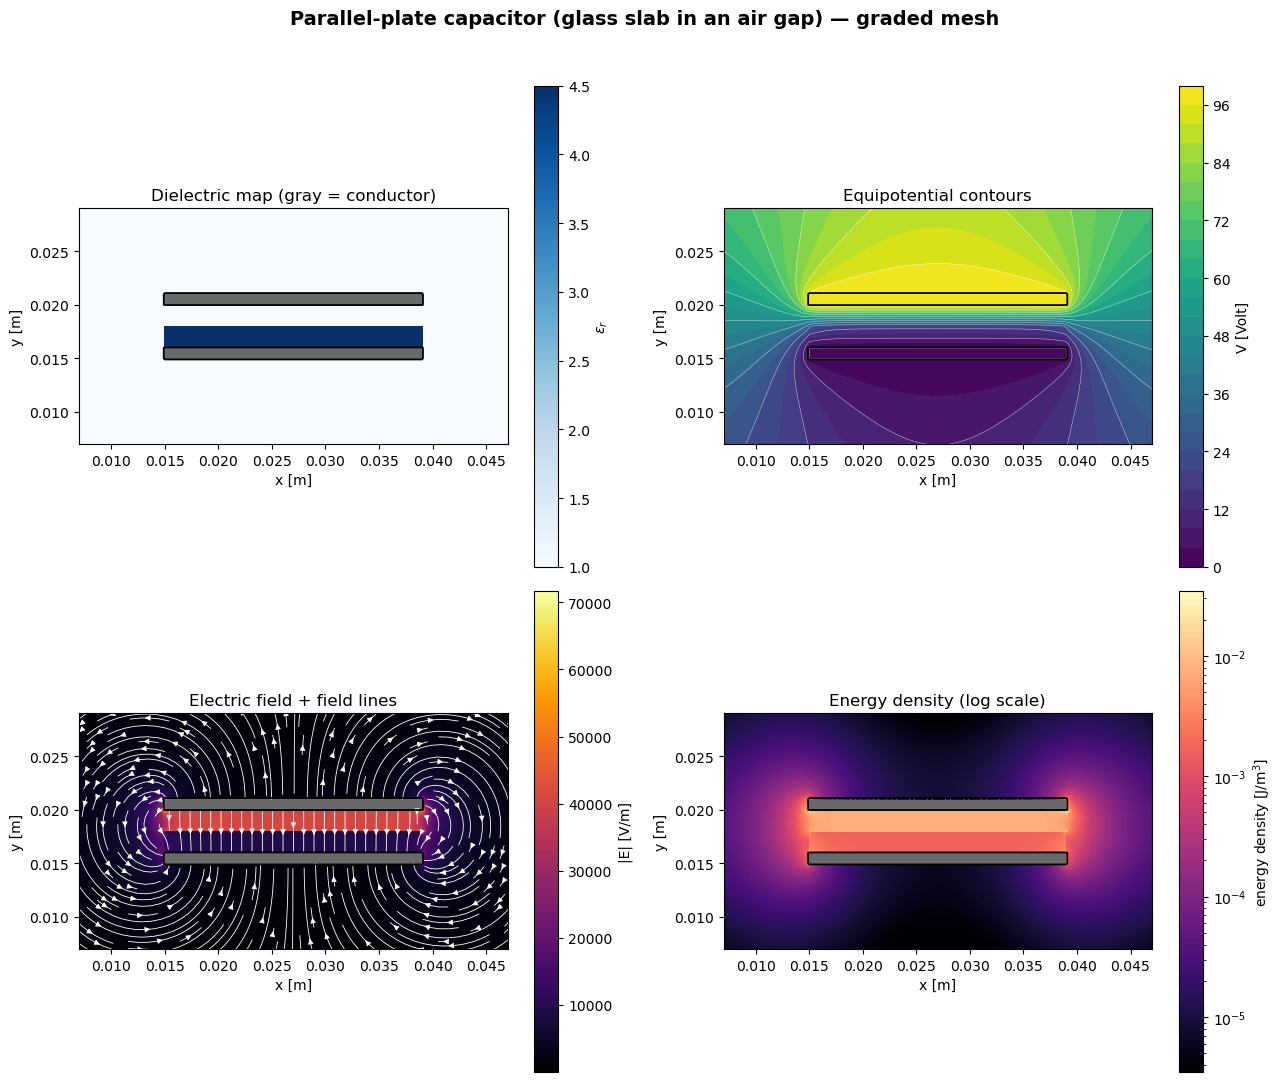


EXAMPLE 2: Coaxial capacitor (polyethylene-filled)
Mesh convergence (smooth circular boundary, no sharp corner):
   h [mm]    nodes  solve [s]    C [pF/m]    error
    0.300    12996      0.017      77.311   -2.76%
    0.200    29241      0.055      78.138   -1.72%
    0.150    51984      0.129      78.495   -1.27%
    0.100   116281      0.463      78.682   -1.03%
    0.075   206116      1.198      78.910   -0.75%
The sequence above is monotonic across every tested resolution.

mesh: 206116 nodes, 410418 triangles (h = 0.075 mm)
FEM capacitance             :    78.910 pF/m
Analytical 2*pi*eps/ln(b/a) :    79.503 pF/m
Difference                  :  -0.75 %  (mesh / staircase discretization error)
Close this plot window to continue to the next figure.


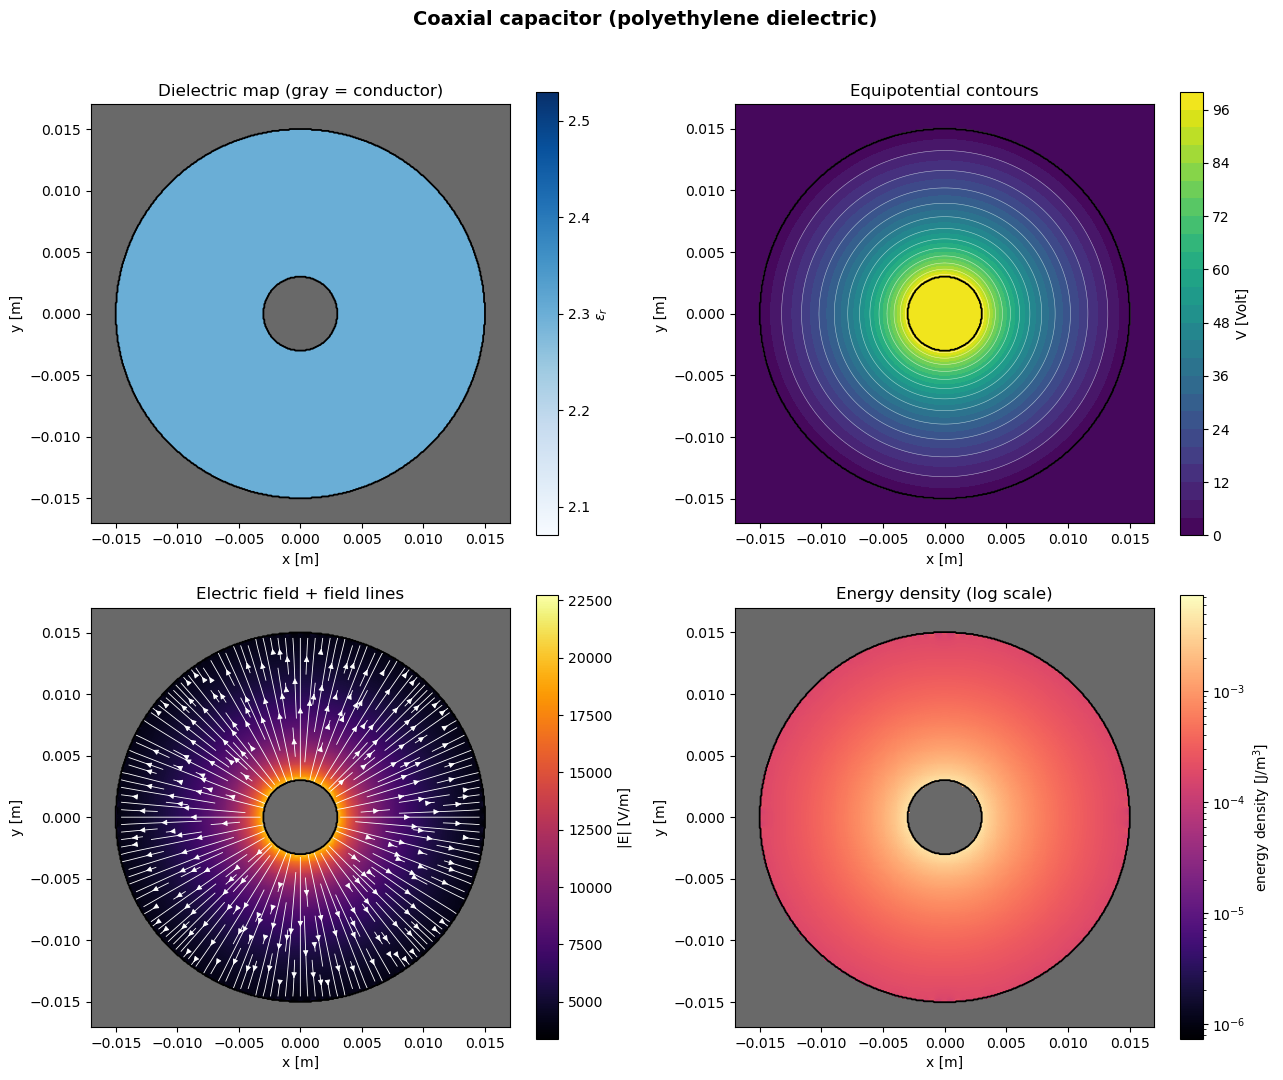

Convergence figure saved to convergence_study.png
Close this convergence plot window to finish.


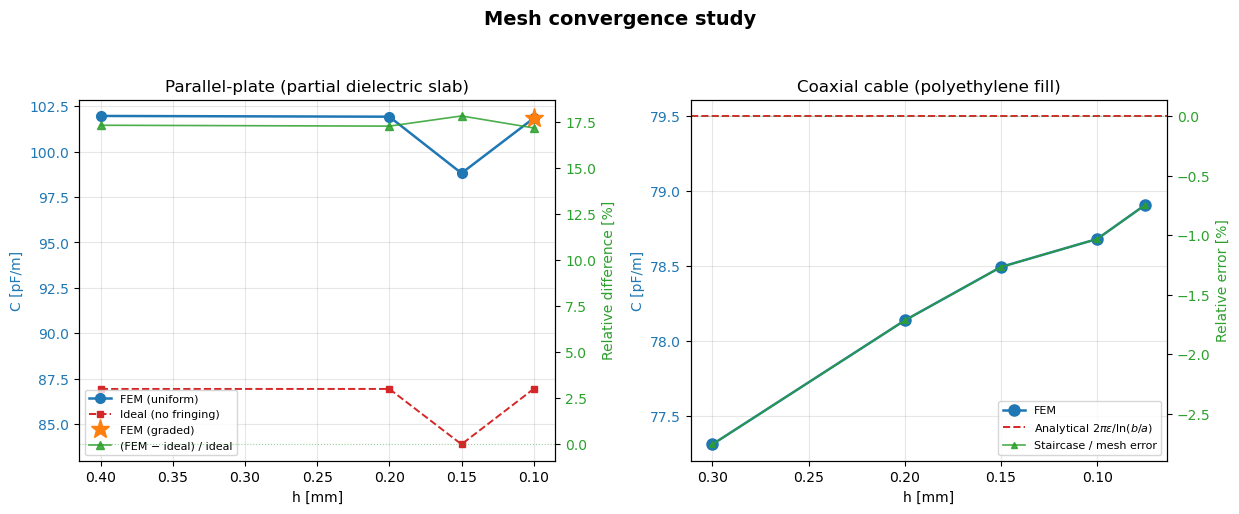


SUMMARY
Case                                  FEM [pF/m]   Analytical [pF/m]
Parallel plate (dielectric slab)         101.881              86.932
Coax (polyethylene)                       78.910              79.503

total runtime: 13.12 s
Figures written under / (example1_parallel_plate.png, example2_coax.png, convergence_study.png)


In [13]:

t_start = time.time()

if RUN_BOUNDARY_STRESS_TEST:
    verify_boundary_tolerance()

if RUN_EXACT_CHECK:
    example_exact_check()
    print()

C1, C1_ideal, pp_results, graded_result = example_parallel_plate()
C2, C2_ideal, coax_results = example_coax()

if PLOT_CONVERGENCE:
    plot_convergence_study(pp_results, coax_results,
                           graded_result=graded_result)

print_summary(C1, C1_ideal, C2, C2_ideal, time.time() - t_start)